<a href="https://colab.research.google.com/github/Auta01/Pytorch/blob/main/Pytorch_image_classification2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --upgrade --quiet

import opendatasets as od
od.download ('https://www.kaggle.com/datasets/andrewmvd/animal-faces')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Auta01
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:11<00:00, 62.9MB/s]

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device available: {device}')

Device available: cpu


In [3]:
image_path = []
labels = []

# Iterate through all directories and collect image paths and labels
for root_dir in os.listdir('/content/animal-faces/afhq'):
    current_set_path = os.path.join('/content/animal-faces/afhq', root_dir)
    if os.path.isdir(current_set_path):
        for label_dir in os.listdir(current_set_path):
            current_label_path = os.path.join(current_set_path, label_dir)
            if os.path.isdir(current_label_path):
                for image_file in os.listdir(current_label_path):
                    image_path.append(os.path.join(current_label_path, image_file))
                    labels.append(label_dir)

print(f"Collected {len(image_path)} images and {len(labels)} labels.")

Collected 16130 images and 16130 labels.


In [4]:
# This cell is no longer needed as its logic has been integrated into P95dl0MU6_bR
# Keeping it empty or removing it ensures no accidental re-execution of partial logic.


In [5]:
data_df = pd.DataFrame(zip(image_path, labels), columns=['image_path', 'labels'])
# Ensure labels are string type to be hashable before calling unique()
data_df['labels'] = data_df['labels'].astype(str)
print(data_df['labels'].unique())

data_df.head()

['dog' 'cat' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
1,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
2,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
3,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
4,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog


In [6]:
data_df.shape

(16130, 2)

In [7]:
train = data_df.sample (frac =0.7)
test = data_df.drop(train.index)

val = test.sample(frac =0.5)
test = test.drop(val.index)

print(train.shape)
print(test.shape)
print(val.shape)

(11291, 2)
(2419, 2)
(2420, 2)


In [8]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)

])

In [9]:
class CustomImageDataset(Dataset):
  def __init__(self, dataFrame, transforms=None):
    self.dataframe = dataFrame  # Store the dataframe correctly
    self.transforms = transforms # Correct attribute name
    self.labels = torch.tensor(label_encoder.transform(self.dataframe['labels'])) # Fix missing parenthesis

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB') # Correct image conversion

    if self.transforms: # Correct attribute name
     image = self.transforms(image).to(device) # Correct attribute name and device assignment

    return image, label

In [10]:
train_dataset =CustomImageDataset(train, transforms =transforms)
val_dataset = CustomImageDataset(val, transforms =transforms)
test_dataset = CustomImageDataset(test, transforms =transforms)

In [11]:
n_rows = 3
n_cols = 3

f, ax = plt.subplots(n_rows, n_cols, figsize=(8, 8))

for row in range(n_rows):
    for col in range(n_cols):
        # Get a random image path from the dataframe
        random_image_path = data_df.sample(n=1)['image_path'].iloc[0]
        image = Image.open(random_image_path).convert('RGB')
        ax[row, col].imshow(image)
        ax[row, col].axis('off') # Turn off axis labels and ticks for cleaner display

plt.tight_layout()
plt.show()

In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS =10



In [ ]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size =BATCH_SIZE, shuffle =True)
test_loader = DataLoader(test_dataset, batch_size =BATCH_SIZE, shuffle =True)

In [14]:
#Building the model
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32,  kernel_size =3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding =1)
    self.conv3 = nn.Conv2d(64,128, kernel_size=3, padding =1)

    self.pooling = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear = nn.Linear(128*16*16, 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique())) # Corrected: .unique() as a method

  def forward(self, x):
    x = self.conv1(x)# --> (32 , 128, 128)
    x = self.pooling(x)#-->(32, 64, 64)
    x = self.relu(x)

    x = self.conv2(x) #-->(64 ,64,64)
    x = self.pooling(x)#-->(64,32,32)
    x = self.relu(x)

    x = self.conv3(x)# -->(128, 32, 32)
    x = self.pooling(x) # -->(128, 16, 16)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)
    return x

In [15]:
#Setting up agnostic code
model = Net().to(device)

In [ ]:
from torchsummary import summary
summary(model, input_size=(3,128,128))

In [ ]:
#Training our model
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


In [18]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_accuracy_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  # Training loop
  model.train() # Set model to training mode
  total_acc_train = 0
  total_loss_train = 0

  for batch_idx, (inputs, labels) in enumerate(train_loader):
    inputs, labels = inputs.to(device), labels.to(device) # Move data to device
    optimizer.zero_grad()

    outputs = model(inputs)
    train_loss = criterion(outputs , labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    train_acc_batch = (torch.argmax(outputs,axis=1)== labels).sum().item() # Correct accuracy calculation for the batch
    total_acc_train += train_acc_batch # Accumulate correct predictions
    optimizer.step()

  # Validation loop
  model.eval() # Set model to evaluation mode
  total_loss_val = 0
  total_acc_val = 0
  with torch.no_grad():
    for batch_idx, (inputs, labels) in enumerate(val_loader):
      inputs, labels = inputs.to(device), labels.to(device) # Move data to device
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()
      val_acc_batch = (torch.argmax(outputs, axis =1)==labels).sum().item() # Correct accuracy calculation for the batch
      total_acc_val += val_acc_batch

  # Store epoch-wise averages for plotting
  total_loss_train_plot.append(round(total_loss_train / len(train_loader), 4)) # Average loss per batch
  total_loss_validation_plot.append(round(total_loss_val / len(val_loader), 4)) # Average loss per batch

  total_accuracy_train_plot.append(round(total_acc_train / len(train_dataset) * 100, 4)) # Total accuracy
  total_acc_validation_plot.append(round(total_acc_val / len(val_dataset) * 100, 4)) # Total accuracy

  # Print epoch results
  print(f'''Epoch {epoch+1}/{EPOCHS},
Train Loss: {total_loss_train_plot[-1]:.4f}, Train Accuracy: {total_accuracy_train_plot[-1]:.2f}%,
Validation Loss: {total_loss_validation_plot[-1]:.4f}, Validation Accuracy: {total_acc_validation_plot[-1]:.2f}%
''')

Epoch 1/10,
Train Loss: 0.4782, Train Accuracy: 79.98%,
Validation Loss: 0.2526, Validation Accuracy: 90.54%

Epoch 2/10,
Train Loss: 0.1967, Train Accuracy: 92.82%,
Validation Loss: 0.1895, Validation Accuracy: 92.69%

Epoch 3/10,
Train Loss: 0.1246, Train Accuracy: 95.77%,
Validation Loss: 0.1320, Validation Accuracy: 95.29%

Epoch 4/10,
Train Loss: 0.0875, Train Accuracy: 96.94%,
Validation Loss: 0.1197, Validation Accuracy: 95.66%

Epoch 5/10,
Train Loss: 0.0633, Train Accuracy: 97.73%,
Validation Loss: 0.1343, Validation Accuracy: 95.37%

Epoch 6/10,
Train Loss: 0.0486, Train Accuracy: 98.20%,
Validation Loss: 0.1151, Validation Accuracy: 96.07%

Epoch 7/10,
Train Loss: 0.0322, Train Accuracy: 98.94%,
Validation Loss: 0.1195, Validation Accuracy: 95.83%

Epoch 8/10,
Train Loss: 0.0265, Train Accuracy: 99.13%,
Validation Loss: 0.1056, Validation Accuracy: 96.78%

Epoch 9/10,
Train Loss: 0.0177, Train Accuracy: 99.50%,
Validation Loss: 0.1154, Validation Accuracy: 96.49%

Epoch 10/1

In [20]:
with torch.no_grad():
   total_loss_test = 0
   total_acc_test = 0

   for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device) # Move data to device
    prediction = model(inputs)

    # Correct accuracy calculation for the batch
    batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()
    total_acc_test += batch_acc

    test_loss = criterion(prediction, labels)
    total_loss_test += test_loss.item()

   # Calculate average accuracy and loss for the test set
   final_test_accuracy = round((total_acc_test / len(test_dataset)) * 100, 4)
   final_test_loss = round(total_loss_test / len(test_loader), 4)

   print(f'Accuracy Score: {final_test_accuracy}% and Loss: {final_test_loss}')

Accuracy Score: 96.8169% and Loss: 0.1092


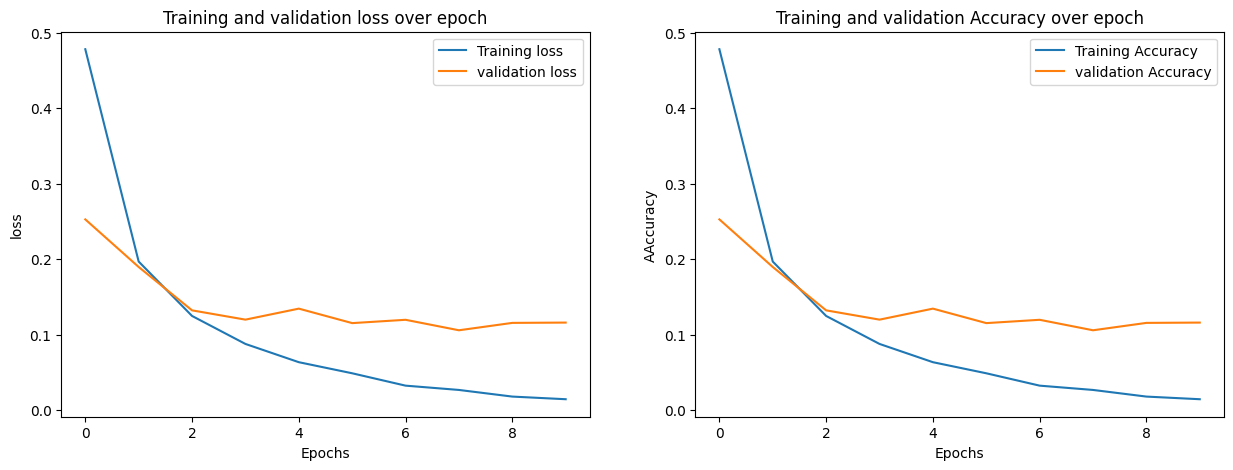

In [23]:
fig, axs = plt.subplots (nrows = 1, ncols =2,  figsize=(15,5))
axs[0].plot(total_loss_train_plot, label ='Training loss')
axs[0].plot(total_loss_validation_plot, label ='validation loss')
axs[0].set_title('Training and validation loss over epoch')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('loss')
axs[0].legend()



axs[1].plot(total_loss_train_plot, label ='Training Accuracy')
axs[1].plot(total_loss_validation_plot, label ='validation Accuracy')
axs[1].set_title('Training and validation Accuracy over epoch')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('AAccuracy')
axs[1].legend()
plt.show()